<a href="https://colab.research.google.com/github/pasteldemisto/computacao_distribuida/blob/main/Computa%C3%A7%C3%A3o_Distribu%C3%ADda_Exerc%C3%ADcios_1_1_e_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computação Distribuída - Exercícios 1.1 e 1.2
### Disponibilidade de Serviços Replicados

###Nome: Jean de Souza Morais
###Matrícula: 2323225

## Exercício 1.1 - Dedução da fórmula de disponibilidade

**Parâmetros:**
- $n$: número de servidores ($n > 0$)
- $k$: número mínimo de servidores disponíveis para o serviço ser acessado de forma consistente ($0 < k \le n$)
- $p$: probabilidade de cada servidor estar disponível em um dado instante ($0 \le p \le 1$)

### Caso k = 1 (operação de consulta)

O serviço fica indisponível apenas se **todos** os servidores estiverem indisponíveis ao mesmo tempo. Usando o complementar:

$$A(n, 1, p) = 1 - (1 - p)^n$$

### Caso k = n (operação de atualização)

O serviço só está disponível se **todos** os $n$ servidores estiverem disponíveis simultaneamente:

$$A(n, n, p) = p^n$$

### Caso geral (k qualquer)

O número de servidores disponíveis segue uma distribuição binomial. Queremos a probabilidade de que **pelo menos k** estejam disponíveis:

$$A(n, k, p) = \sum_{i=k}^{n} \binom{n}{i}\, p^i (1-p)^{n-i}$$

Onde:
- $i$ percorre todos os cenários possíveis de "exatamente $i$ disponíveis", de $k$ até $n$
- $\binom{n}{i}$ conta de quantas formas podemos escolher quais $i$ servidores (dentre os $n$) estão disponíveis
- $p^i$ é a probabilidade de esses $i$ servidores estarem todos disponíveis
- $(1-p)^{n-i}$ é a probabilidade dos $n-i$ restantes estarem todos indisponíveis

**Verificação dos casos extremos:**
- Se $k=n$: a soma tem um único termo ($i=n$), resultando em $p^n$ ✓
- Se $k=1$: a soma cobre tudo exceto $i=0$; como a soma total (i=0 até n) vale 1, sobra $1-(1-p)^n$ ✓

**Nota sobre o caso intermediário:** como caso de comparação intermediário, usamos $k = \lfloor n/2 \rfloor + 1$ — o quórum de maioria, que é sempre um inteiro (não faz sentido "meio servidor"). Esse é o valor de $k$ usado, por exemplo, em algoritmos de consenso como Raft e Paxos, justamente para garantir que não existam duas maiorias simultâneas em partições diferentes da rede.


## Exercício 1.2 — Parte 1: Cálculo analítico

### Implementação da fórmula

In [ ]:
from math import comb
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def disponibilidade_binomial(n: int, k: int, p: float) -> float:
    """
    Calcula a disponibilidade A(n, k, p) de um servico replicado
    em n servidores, exigindo pelo menos k disponiveis, onde cada
    servidor tem probabilidade p de estar disponivel.
    """
    return sum(comb(n, i) * (p ** i) * ((1 - p) ** (n - i)) for i in range(k, n + 1))

# Teste rapido usando o exemplo discutido: n=2, p=0.9
n, p = 2, 0.9
print(f"A(n={n}, k=1, p={p}) = {disponibilidade_binomial(n, 1, p):.4f}")
print(f"A(n={n}, k={n}, p={p}) = {disponibilidade_binomial(n, n, p):.4f}")

A(n=2, k=1, p=0.9) = 0.9900
A(n=2, k=2, p=0.9) = 0.8100


### Tabela comparativa (k = 1, n/2, n)

In [ ]:
def gerar_tabela(n: int, valores_p: list) -> pd.DataFrame:
    """
    Gera uma tabela comparando a disponibilidade A(n, k, p) para os
    casos k=1, k=maioria (n//2 + 1) e k=n, variando p.
    """
    k_maioria = n // 2 + 1
    ks = {"k=1": 1, f"k={k_maioria} (maioria)": k_maioria, f"k={n}": n}
    dados = {"p": valores_p}
    for label, k in ks.items():
        dados[label] = [disponibilidade_binomial(n, k, p) for p in valores_p]
    return pd.DataFrame(dados)

n = 5
valores_p = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
tabela = gerar_tabela(n, valores_p)
tabela

,p,k=1,k=3 (maioria),k=5
0,0.50,0.96875,0.500000,0.031250
1,0.70,0.99757,0.836920,0.168070
2,0.80,0.99968,0.942080,0.327680
3,0.90,0.99999,0.991440,0.590490
4,0.95,1.00000,0.998842,0.773781
5,0.99,1.00000,0.999990,0.950990


### Gráfico 2D — Disponibilidade x p

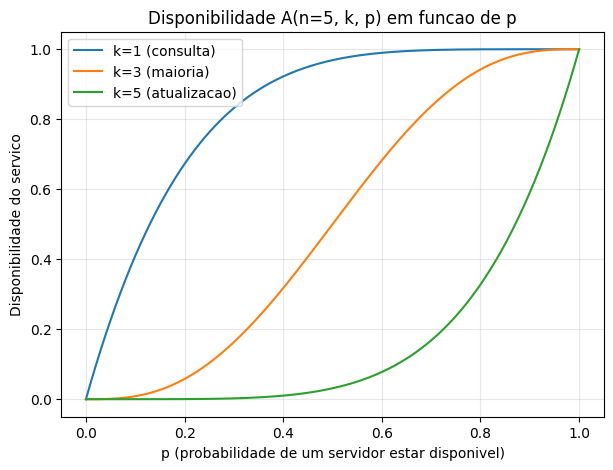

In [ ]:
def plotar_disponibilidade(n: int):
    """
    Plota curvas de disponibilidade A(n, k, p) em funcao de p,
    para k=1, k=n/2 (arredondado) e k=n.
    """
    ps = np.linspace(0, 1, 200)
    k_maioria = n // 2 + 1
    ks = {"k=1 (consulta)": 1, f"k={k_maioria} (maioria)": k_maioria, f"k={n} (atualizacao)": n}

    plt.figure(figsize=(7, 5))
    for label, k in ks.items():
        valores = [disponibilidade_binomial(n, k, p) for p in ps]
        plt.plot(ps, valores, label=label)

    plt.title(f"Disponibilidade A(n={n}, k, p) em funcao de p")
    plt.xlabel("p (probabilidade de um servidor estar disponivel)")
    plt.ylabel("Disponibilidade do servico")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plotar_disponibilidade(n=5)

## Exercício 1.2 - Parte 2: Simulador estocástico

### Implementação do simulador

In [ ]:
def simular_disponibilidade(n: int, k: int, p: float, rodadas: int = 100_000) -> float:
    """
    Simula 'rodadas' tentativas de acesso a um servico replicado em n
    servidores, cada um disponivel com probabilidade p. Retorna a
    frequencia experimental de rodadas em que pelo menos k servidores
    estavam disponiveis.
    """
    sucessos = 0
    for _ in range(rodadas):
        disponiveis = sum(1 for _ in range(n) if random.random() <= p)
        if disponiveis >= k:
            sucessos += 1
    return sucessos / rodadas

# Teste: comparar com os valores analiticos ja calculados (n=2, p=0.9)
random.seed(42)
n, p = 2, 0.9
for k in (1, n):
    analitico = disponibilidade_binomial(n, k, p)
    experimental = simular_disponibilidade(n, k, p, rodadas=100_000)
    print(f"k={k}: analitico={analitico:.4f}  experimental={experimental:.4f}")

k=1: analitico=0.9900  experimental=0.9897
k=2: analitico=0.8100  experimental=0.8093


### Tabela comparativa - Analítico vs. Experimental

In [ ]:
def gerar_tabela_comparativa(n: int, valores_p: list, rodadas: int = 50_000) -> pd.DataFrame:
    """
    Gera uma tabela comparando disponibilidade analitica vs experimental
    para k=1, k=maioria (n//2 + 1) e k=n, variando p.
    """
    k_maioria = n // 2 + 1
    ks = {"k=1": 1, f"k={k_maioria} ": k_maioria, f"k={n}": n}
    linhas = []
    for p in valores_p:
        linha = {"p": p}
        for label, k in ks.items():
            linha[f"{label} (analitico)"] = disponibilidade_binomial(n, k, p)
            linha[f"{label} (experimental)"] = simular_disponibilidade(n, k, p, rodadas)
        linhas.append(linha)
    return pd.DataFrame(linhas)

random.seed(42)
n = 5
valores_p = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
tabela_comp = gerar_tabela_comparativa(n, valores_p)
tabela_comp

,p,k=1 (analitico),k=1 (experimental),k=3 (analitico),k=3 (experimental),k=5 (analitico),k=5 (experimental)
0,0.50,0.96875,0.96806,0.500000,0.49878,0.031250,0.03204
1,0.70,0.99757,0.99786,0.836920,0.83538,0.168070,0.16858
2,0.80,0.99968,0.99968,0.942080,0.94084,0.327680,0.33050
3,0.90,0.99999,1.00000,0.991440,0.99226,0.590490,0.58960
4,0.95,1.00000,1.00000,0.998842,0.99858,0.773781,0.77784
5,0.99,1.00000,1.00000,0.999990,0.99996,0.950990,0.95138


### Gráfico comparativo - Analítico (linha) vs. Experimental (pontos)

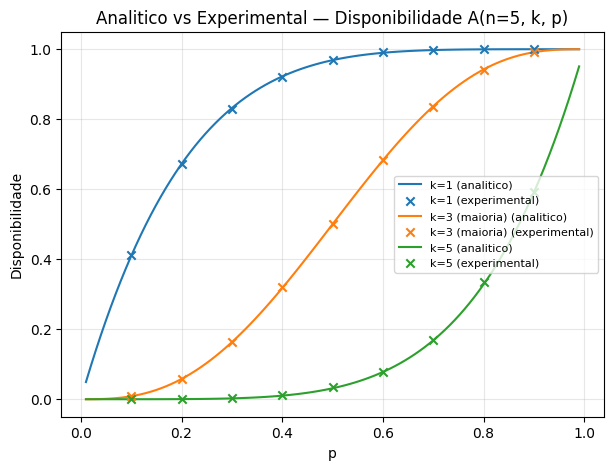

In [ ]:
def plotar_comparativo(n: int, rodadas: int = 20_000):
    """
    Plota, para k=1, k=n/2 e k=n, a curva analitica continua de
    disponibilidade e sobrepoe pontos experimentais (simulados) para
    visualizar a aproximacao entre teoria e pratica.
    """
    ps_analitico = np.linspace(0.01, 0.99, 100)
    ps_experimental = np.linspace(0.1, 0.9, 9)
    k_maioria = n // 2 + 1
    ks = {"k=1": 1, f"k={k_maioria} (maioria)": k_maioria, f"k={n}": n}
    cores = {"k=1": "tab:blue", f"k={k_maioria} (maioria)": "tab:orange", f"k={n}": "tab:green"}

    plt.figure(figsize=(7, 5))
    for label, k in ks.items():
        curva = [disponibilidade_binomial(n, k, p) for p in ps_analitico]
        plt.plot(ps_analitico, curva, label=f"{label} (analitico)", color=cores[label])

        pontos = [simular_disponibilidade(n, k, p, rodadas) for p in ps_experimental]
        plt.scatter(ps_experimental, pontos, label=f"{label} (experimental)",
                    color=cores[label], marker="x", zorder=5)

    plt.title(f"Analitico vs Experimental — Disponibilidade A(n={n}, k, p)")
    plt.xlabel("p")
    plt.ylabel("Disponibilidade")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.show()

random.seed(42)
plotar_comparativo(n=5)